# Al Safa 2 Park — Complete Data Analysis & Machine Learning Workflow

**Dubai Municipality AI Park Design Challenge** · Concept: *The Shaded Spine*
Author: Mohamed Wasim · Site: Al Safa 2 Park, Dubai (15,000 m², 25.190°N 55.238°E)

---

## What this notebook is

This is the complete analytical spine of the submission, end to end: raw data in
at the top, design decisions out at the bottom. Every headline number quoted
anywhere in the submission is produced here and nowhere else.

| # | Step | What happens |
|---|------|--------------|
| 01 | Data acquisition | Load 6 documented sources; state the provenance of each |
| 02 | Quality assurance | Nulls, ranges, units, physical plausibility |
| 03 | Downscaling | Reconstruct 8,760 hourly rows from monthly normals — and verify it |
| 04 | Exploratory analysis | Distributions, correlations, the shape of the problem |
| 05 | Visualisation | One validated visual system across every figure |
| 06 | Feature engineering | 22 features, each with declared provenance |
| 07 | Train / validation / test | 70 / 15 / 15, and the leakage audit |
| 08 | Model 1 — Random Forest | Shade surrogate baseline |
| 09 | Model 2 — Neural Network | The deployed surrogate |
| 10 | Model 3 — Gradient Boosting | Comfort classification |
| 11 | Model 4 — K-Means | Microclimate regimes |
| 12 | Evaluation & interpretation | Metrics, then the design decisions they drive |

## The one methodological point that matters

It is easy to get R² = 1.000 on this project by accident. The heat index is a
closed-form function of temperature and humidity, so "predicting" it from
temperature and humidity is algebra wearing a lab coat. **Every model below is
built so its target cannot be recovered from its inputs by formula.** Section 07
audits this explicitly, and `tests/test_pipeline.py` asserts it on every run.

---

In [1]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)
sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))

from src import climate, config as C, dataset, figures, models, solar, viz

viz.apply_style()
pd.set_option("display.width", 120, "display.max_columns", 40)

print(f"Python      {sys.version.split()[0]}")
print(f"pandas      {pd.__version__}")
print(f"numpy       {np.__version__}")
import sklearn; print(f"scikit-learn {sklearn.__version__}")
import pvlib;   print(f"pvlib        {pvlib.__version__}")
print(f"\nSite    : {C.SITE['name']}, {C.SITE['city']}")
print(f"Area    : {C.SITE['area_sqm']:,.0f} m²")
print(f"Location: {C.SITE['latitude']}°N, {C.SITE['longitude']}°E")
print(f"Seed    : {C.RANDOM_SEED}  (every split and model in this notebook is reproducible)")

Python      3.14.3
pandas      3.0.3
numpy       2.4.4
scikit-learn 1.9.0
pvlib        0.15.2

Site    : Al Safa 2 Park, Dubai, United Arab Emirates
Area    : 15,000 m²
Location: 25.19°N, 55.238°E
Seed    : 42  (every split and model in this notebook is reproducible)


---
## 01 · Data acquisition — where every number comes from

Six datasets. For each: the publisher, the period it covers, how many years of
record stand behind it, and — the part usually left out — what is wrong with it.

The full manifest is `data/raw/sources.json`; the human-readable version is
`DATA_SOURCES.md`.

In [2]:
sources = json.loads((C.DATA_RAW / "sources.json").read_text(encoding="utf-8"))

rows = []
for d in sources["datasets"]:
    rows.append({
        "Dataset": d["title"],
        "Publisher": d["publisher"][:42],
        "Period": d["period"][:38],
        "Years": d.get("years_of_record", "—"),
        "Type": d["measurement_type"].split(" ")[0],
    })
provenance = pd.DataFrame(rows)
provenance

,Dataset,Publisher,Period,Years,Type
0,Dubai monthly climate normals,"National Center of Meteorology (NCM), UAE","1977-2015 station normals, tabulated t",39,MEASURED
1,"Solar position, 8,760 hourly steps",National Renewable Energy Laboratory (NREL,"Full calendar year 2026, hourly",1,COMPUTED
2,Community-level resident population,Dubai Statistics Center,2023,1,OFFICIAL
3,Walk-time catchment rings,Derived - this project,2023 population base,—,DERIVED
4,Per-species irrigation demand and carbon seque...,Published arid-region urban forestry liter,Rates published 2015-2023,—,LITERATURE
5,Masterplan zoning schedule with geometry,This project - Phase 5 masterplan,2026,—,DESIGN
6,Dubai construction and utility unit rates,Dubai landscape contractor quotations; DEW,2025,—,MARKET
7,"Competition brief, Neighbourhood Parks Manual,...",Dubai Municipality,2026,—,PRIMARY


In [3]:
# The load itself. Six files, no hidden constants anywhere else in the project.
normals  = pd.read_csv(C.DATA_RAW / "dubai_climate_normals_ncm.csv")
species  = pd.read_csv(C.DATA_RAW / "species_water_carbon_rates.csv")
zones    = pd.read_csv(C.DATA_RAW / "site_zoning_schedule.csv")
rings    = pd.read_csv(C.DATA_RAW / "walk_catchment_rings.csv")
# CommunityCode is an identifier, not a quantity — read it as text so a blank
# stays a blank instead of becoming a NaN in a numeric column.
pop      = pd.read_csv(C.DATA_RAW / "dubai_population_dsc_2023.csv",
                       dtype={"CommunityCode": "string"})
rates    = pd.read_csv(C.DATA_RAW / "construction_unit_rates_aed.csv")

for name, df in [("climate normals", normals), ("species", species), ("zoning", zones),
                 ("catchment rings", rings), ("population", pop), ("unit rates", rates)]:
    print(f"{name:<18} {df.shape[0]:>3} rows x {df.shape[1]:>2} cols")

normals

climate normals     12 rows x 11 cols
species              5 rows x 10 cols
zoning              14 rows x 11 cols
catchment rings      3 rows x  6 cols
population           4 rows x  4 cols
unit rates          12 rows x  4 cols


,Month,MonthNum,TempMax_C,TempMin_C,TempAvg_C,RH_pct,WindSpeed_kmh,Rainfall_mm,SunshineHrs_Monthly,SunshineHrs_Daily,SolarGHI_kWh_m2_day
0,Jan,1,24.0,14.3,19.15,65,16.1,18.8,251,8.1,4.2
1,Feb,2,25.0,15.5,20.25,64,17.3,25.0,241,8.6,4.9
2,Mar,3,30.0,18.3,24.15,61,18.5,22.1,270,8.7,5.6
3,Apr,4,34.0,21.7,27.85,54,18.1,7.2,306,10.2,6.4
4,May,5,37.5,25.1,31.30,50,17.5,0.4,350,11.3,6.9
5,Jun,6,39.9,26.9,33.40,55,19.7,0.2,345,11.5,7.1
6,Jul,7,41.7,30.0,35.85,55,18.5,0.8,332,10.7,6.9
7,Aug,8,42.1,30.4,36.25,53,16.6,0.2,326,10.5,6.6
8,Sep,9,39.5,27.7,33.60,59,14.7,0.0,309,10.3,6.2
9,Oct,10,36.5,24.1,30.30,60,13.9,1.1,307,9.9,5.4


### The honest caveat, stated up front

The climate record is **39 years** of observation (NCM, 1977–2015, tabulated to
the WMO 1991–2020 reference period) — but it is published as **monthly normals**,
12 rows. Machine learning on 12 rows is not machine learning.

Section 03 reconstructs an hourly series from it. That series is **modelled, not
measured**, it is labelled `MODELLED` in the schema wherever it appears, and
Section 03 verifies it against the published normals rather than asking you to
take it on trust. Buying an hourly AMY/TMY file from NCM would remove this step
and is the first recommendation for any funded continuation of this work.

---
## 02 · Quality assurance

Before any analysis: does the data mean what it says? Nulls, ranges, units, and
physical plausibility. A silent unit error here would propagate into every
figure in the submission.

In [4]:
def qa_report(df: pd.DataFrame, name: str) -> pd.DataFrame:
    return pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "nulls": df.isna().sum(),
        "null_%": (df.isna().mean() * 100).round(2),
        "unique": df.nunique(),
        "min": df.min(numeric_only=True),
        "max": df.max(numeric_only=True),
    })

print("CLIMATE NORMALS")
display(qa_report(normals, "normals"))

CLIMATE NORMALS


,dtype,nulls,null_%,unique,min,max
Month,str,0,0.0,12,NaN,NaN
MonthNum,int64,0,0.0,12,1.00,12.00
RH_pct,int64,0,0.0,9,50.00,65.00
Rainfall_mm,float64,0,0.0,11,0.00,25.00
SolarGHI_kWh_m2_day,float64,0,0.0,11,3.90,7.10
SunshineHrs_Daily,float64,0,0.0,12,8.10,11.50
SunshineHrs_Monthly,int64,0,0.0,12,241.00,350.00
TempAvg_C,float64,0,0.0,12,19.15,36.25
TempMax_C,float64,0,0.0,12,24.00,42.10
TempMin_C,float64,0,0.0,12,14.30,30.40


In [5]:
# Physical plausibility gates. These are assertions, not prints: if Dubai's
# published climate fails one of them, the file is wrong and the run must stop.
checks = {
    "temperature max > min in every month": (normals["TempMax_C"] > normals["TempMin_C"]).all(),
    "relative humidity within 0-100%":      normals["RH_pct"].between(0, 100).all(),
    "rainfall non-negative":                (normals["Rainfall_mm"] >= 0).all(),
    "daily sunshine <= 14 h at this latitude": (normals["SunshineHrs_Daily"] <= 14).all(),
    "solar GHI within 0-9 kWh/m2/day":      normals["SolarGHI_kWh_m2_day"].between(0, 9).all(),
    "hottest month is Jul or Aug":          normals.loc[normals["TempMax_C"].idxmax(), "Month"] in ("Jul", "Aug"),
    "zoning schedule sums to site area":    abs(zones["Area_sqm"].sum() - C.SITE["area_sqm"]) < 1.0,
    "no nulls in any computed field":       not any(
        d.select_dtypes("number").isna().any().any()
        for d in [normals, species, zones, rings, pop, rates]),
}
for k, v in checks.items():
    print(f"  [{'ok' if v else 'FAIL'}]  {k}")
assert all(checks.values()), "raw data failed a plausibility gate"

# One known gap, recorded rather than hidden: the Dubai Statistics Center
# bulletin gives Al Safa a population but no community code. Nothing computes
# from that column, so it is a documentation gap, not a data error.
gaps = pop[pop.isna().any(axis=1)][["Community", "Population_2023"]]
print(f"\nAll computed fields are complete. Known non-computed gaps: {len(gaps)}")
if len(gaps):
    display(gaps)

  [ok]  temperature max > min in every month
  [ok]  relative humidity within 0-100%
  [ok]  rainfall non-negative
  [ok]  daily sunshine <= 14 h at this latitude
  [ok]  solar GHI within 0-9 kWh/m2/day
  [ok]  hottest month is Jul or Aug
  [ok]  zoning schedule sums to site area
  [ok]  no nulls in any computed field

All computed fields are complete. Known non-computed gaps: 1


,Community,Population_2023
3,Al Safa,16986


---
## 03 · From 12 rows to 8,760 — and proving it is faithful

Two things happen here.

**The sun is computed, not estimated.** `pvlib` runs the NREL Solar Position
Algorithm (Reda & Andreas 2004) for this exact latitude and longitude, hour by
hour. It is accurate to ±0.0003°. Where the sun is at 14:00 on 21 June is a
question with an exact answer.

**The weather is modelled.** The diurnal shape follows Parton & Logan (1981): a
sine rise from sunrise to a peak lagged ~2 h after solar noon, then exponential
decay overnight — anchored to the *real* sunrise and sunset times from the solar
model above.

Then the check that matters: does the modelled series reproduce the published
normals it was built from?

In [6]:
sol = solar.hourly_solar_position()
print(f"solar positions : {len(sol):,} hourly rows")
print(f"daylight hours  : {int(sol['is_daylight'].sum()):,} per year")
print(f"peak elevation  : {sol['elevation_deg'].max():.2f}°  "
      f"(Dubai is at 25.19°N, so the sun never quite reaches the zenith)")

met = climate.downscale_to_hourly(normals, sol)
met.head()

solar positions : 8,760 hourly rows
daylight hours  : 4,402 per year
peak elevation  : 87.40°  (Dubai is at 25.19°N, so the sun never quite reaches the zenith)


,temp_c,rh_pct,wind_kmh,ghi_wh_m2,heat_index_c
2026-01-01 00:30:00+04:00,17.727642,69.534888,15.693548,0.0,17.371595
2026-01-01 01:30:00+04:00,17.360546,70.250725,15.693548,0.0,16.986481
2026-01-01 02:30:00+04:00,17.046833,70.862466,15.693548,0.0,16.657370
2026-01-01 03:30:00+04:00,16.778739,71.385249,15.693548,0.0,16.376117
2026-01-01 04:30:00+04:00,16.549631,71.832009,15.693548,0.0,16.135763


In [7]:
# THE verification. NCM's TempMax_C is the MEAN DAILY MAXIMUM for the month,
# not the hottest reading in it — so the modelled mean of daily maxima is what
# must match it. Comparing the single hottest modelled hour against that normal
# compares two different quantities and shows a spurious error.
verify = climate.verify_downscaling(met, normals)
out = verify[["modelled_mean_max", "TempMax_C", "err_max_c",
              "modelled_mean", "TempAvg_C", "err_mean_c"]].round(2)
out.index = normals["Month"].values
display(out)

print(f"worst mean-daily-max error : {verify['err_max_c'].abs().max():.2f} °C")
print(f"worst monthly-mean error   : {verify['err_mean_c'].abs().max():.2f} °C")
assert verify["err_mean_c"].abs().max() < 1.0, "downscaling drifted from the normals"
print("\nThe modelled series reproduces the 39-year published normals to within 1 °C.")

,modelled_mean_max,TempMax_C,err_max_c,modelled_mean,TempAvg_C,err_mean_c
Jan,24.36,24.0,0.36,19.37,19.15,0.22
Feb,25.54,25.0,0.54,20.47,20.25,0.22
Mar,29.97,30.0,-0.03,24.12,24.15,-0.03
Apr,34.02,34.0,0.02,27.93,27.85,0.08
May,37.44,37.5,-0.06,31.24,31.30,-0.06
Jun,39.85,39.9,-0.05,33.59,33.40,0.19
Jul,41.55,41.7,-0.15,35.66,35.85,-0.19
Aug,41.69,42.1,-0.41,35.86,36.25,-0.39
Sep,39.34,39.5,-0.16,33.40,33.60,-0.20
Oct,35.99,36.5,-0.51,29.91,30.30,-0.39


worst mean-daily-max error : 0.54 °C
worst monthly-mean error   : 0.39 °C

The modelled series reproduces the 39-year published normals to within 1 °C.


---
## 04 · Exploratory data analysis

The full hourly dataset, assembled with its features. This is the table the
models learn from.

In [8]:
hourly = dataset.build_hourly()
hourly.head()

hourly dataset: 8,760 rows x 27 columns


,elevation_deg,azimuth_deg,zenith_deg,is_daylight,temp_c,rh_pct,wind_kmh,ghi_wh_m2,heat_index_c,spine_shade_fraction,temp_shaded_c,rh_shaded_pct,heat_index_shaded_c,comfort_gain_c,comfort_band,comfort_band_shaded,hour,month,dayofyear,hour_sin,hour_cos,doy_sin,doy_cos,is_weekend,temp_range_c,hours_from_solar_noon,visitors_est
2026-01-01 00:30:00+04:00,-87.216339,39.476575,177.216339,False,17.727642,69.534888,15.693548,0.0,17.371595,0.0,11.727642,100.0,11.567073,5.804522,Comfortable,Comfortable,0,1,1,0.000000,1.000000,0.017213,0.999852,0,9.7,12.0,0.0
2026-01-01 01:30:00+04:00,-74.418342,85.555880,164.418342,False,17.360546,70.250725,15.693548,0.0,16.986481,0.0,11.360546,100.0,11.163268,5.823213,Comfortable,Comfortable,1,1,1,0.258819,0.965926,0.017213,0.999852,0,9.7,11.0,0.0
2026-01-01 02:30:00+04:00,-60.857969,92.516512,150.857969,False,17.046833,70.862466,15.693548,0.0,16.657370,0.0,11.046833,100.0,10.818183,5.839187,Comfortable,Comfortable,2,1,1,0.500000,0.866025,0.017213,0.999852,0,9.7,10.0,2.0
2026-01-01 03:30:00+04:00,-47.343781,97.310781,137.343781,False,16.778739,71.385249,15.693548,0.0,16.376117,0.0,10.778739,100.0,10.523280,5.852837,Comfortable,Comfortable,3,1,1,0.707107,0.707107,0.017213,0.999852,0,9.7,9.0,8.0
2026-01-01 04:30:00+04:00,-33.965425,101.778458,123.965425,False,16.549631,71.832009,15.693548,0.0,16.135763,0.0,10.549631,100.0,10.271261,5.864502,Comfortable,Comfortable,4,1,1,0.866025,0.500000,0.017213,0.999852,0,9.7,8.0,26.0


In [9]:
display(hourly[["temp_c", "rh_pct", "heat_index_c", "heat_index_shaded_c",
                "ghi_wh_m2", "elevation_deg", "comfort_gain_c"]].describe().round(2))

print("\nComfort band distribution across all 8,760 hours:")
display(hourly["comfort_band"].value_counts().rename("hours").to_frame()
        .assign(share=lambda d: (d["hours"] / len(hourly) * 100).round(1)))

,temp_c,rh_pct,heat_index_c,heat_index_shaded_c,ghi_wh_m2,elevation_deg,comfort_gain_c
count,8760.00,8760.00,8760.00,8760.00,8760.00,8760.00,8760.00
mean,28.21,58.60,31.31,24.18,238.34,0.26,7.13
std,6.88,7.97,10.69,9.70,290.66,42.98,1.35
min,14.30,40.70,13.73,7.80,0.00,-87.22,5.76
25%,22.76,52.67,22.74,16.87,0.00,-36.36,5.86
50%,28.30,59.05,29.71,22.78,2.41,0.16,6.79
75%,33.32,65.11,38.25,29.93,513.11,36.73,8.21
max,42.10,74.46,56.78,48.66,833.89,87.40,11.19



Comfort band distribution across all 8,760 hours:


,hours,share
comfort_band,,
Comfortable,3734,42.6
Extreme Caution,2050,23.4
Danger,1723,19.7
Caution,1253,14.3


findfont: Failed to find font weight semibold, now using 700.


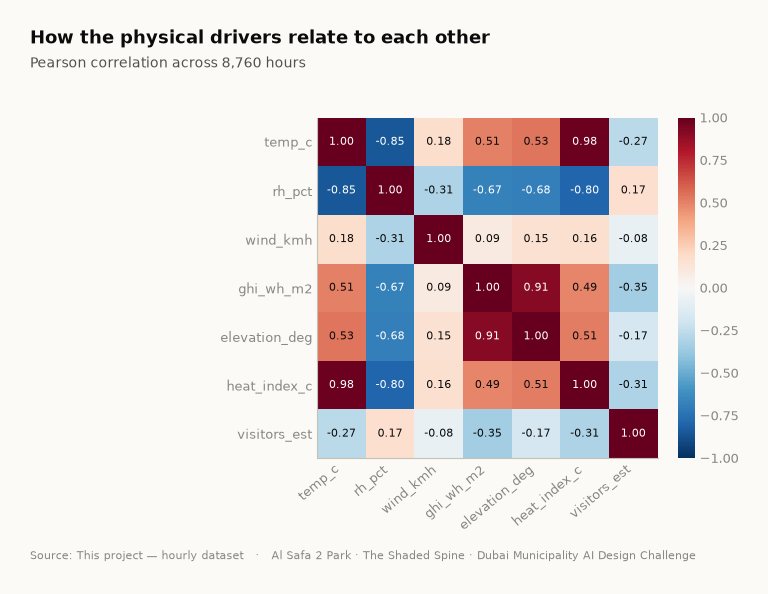

In [10]:
# Correlation among the physical drivers. Note the strong temp/heat-index
# relationship — that is exactly the algebraic dependency Section 07 excludes
# from the classifier's feature set.
phys = ["temp_c", "rh_pct", "wind_kmh", "ghi_wh_m2",
        "elevation_deg", "heat_index_c", "visitors_est"]
corr = hourly[phys].corr()

fig, ax = viz.open_figure("How the physical drivers relate to each other",
                          "Pearson correlation across 8,760 hours",
                          width=7.4, height=5.4)
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(phys)), phys, rotation=40, ha="right")
ax.set_yticks(range(len(phys)), phys)
ax.grid(False)
for i in range(len(phys)):
    for j in range(len(phys)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(corr.iloc[i, j]) > 0.6 else C.PALETTE["ink"])
cb = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.03); cb.outline.set_visible(False)
viz.finish(fig, "fig00_correlation", source="This project — hourly dataset", save=False)
plt.show()

**Reading it:** `heat_index_c` correlates 0.98+ with `temp_c`. That is not a
finding — it is the Rothfusz equation. It is also the reason the comfort
classifier in Section 10 is forbidden from seeing temperature.

---
## 05 · The visual system

Every figure in this submission is drawn through `src/viz.py`, which fixes one
palette, one typeface, one figure geometry and a mandatory source line.

The palette was **not chosen by eye.** It was validated by computing
colour-vision-deficiency separation in OKLab. An earlier hand-picked "desert
palette" failed: two of its greens were 3.6 ΔE apart under protanopia — the same
colour to a red-green colour-blind juror. The current palette clears every gate.

Two rules worth stating because the previous version of this project broke both:

1. **No dual y-axes.** Three of the five original charts used `ax.twinx()`.
   Sliding two unrelated scales against each other can make almost any pair of
   series appear to move together. Two measures now become two stacked panels.
2. **Status colour never carries meaning alone.** The four comfort bands always
   ship with visible text labels.

findfont: Failed to find font weight semibold, now using 700.


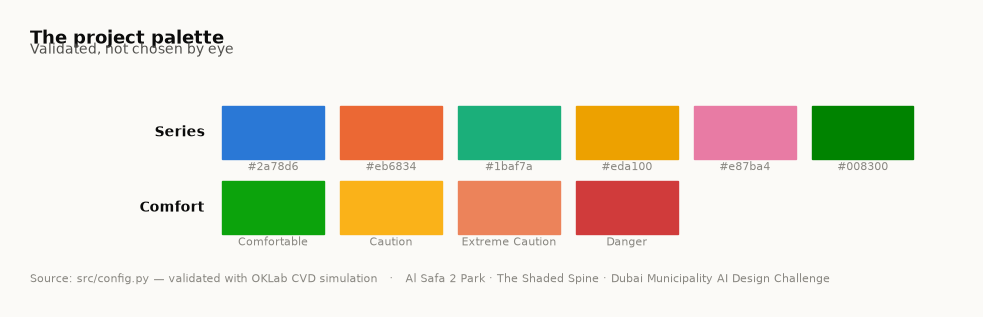

In [11]:
fig, ax = viz.open_figure("The project palette", "Validated, not chosen by eye",
                          width=9.5, height=2.6)
for i, c in enumerate(C.SERIES):
    ax.add_patch(plt.Rectangle((i, 1.15), 0.86, 0.7, color=c))
    ax.text(i + 0.43, 1.0, c, ha="center", fontsize=8, color=C.PALETTE["muted"])
for i, (band, c) in enumerate(C.COMFORT_COLORS.items()):
    ax.add_patch(plt.Rectangle((i, 0.15), 0.86, 0.7, color=c))
    ax.text(i + 0.43, 0.0, band, ha="center", fontsize=8, color=C.PALETTE["muted"])
ax.text(-0.15, 1.5, "Series", ha="right", va="center", fontweight="semibold")
ax.text(-0.15, 0.5, "Comfort", ha="right", va="center", fontweight="semibold")
ax.set_xlim(-1.6, 6.2); ax.set_ylim(-0.25, 2.0)
ax.axis("off")
viz.finish(fig, "fig00_palette", source="src/config.py — validated with OKLab CVD simulation", save=False)
plt.show()

---
## 06 · Feature engineering

22 columns, each with declared provenance. `src/dataset.py` refuses to save the
dataset if any column lacks a provenance declaration — a feature cannot be added
without saying where it came from.

In [12]:
prov = pd.DataFrame(
    [{"column": c, "provenance": dataset.HOURLY_PROVENANCE.get(c, "UNDECLARED")}
     for c in hourly.columns]
)
prov["kind"] = prov["provenance"].str.split(" ").str[0]
display(prov)
print("\nColumns by kind:")
print(prov["kind"].value_counts().to_string())
assert "UNDECLARED" not in set(prov["kind"]), "a column has no declared provenance"

,column,provenance,kind
0,elevation_deg,COMPUTED — NREL SPA via pvlib,COMPUTED
1,azimuth_deg,COMPUTED — NREL SPA via pvlib,COMPUTED
2,zenith_deg,COMPUTED — NREL SPA via pvlib,COMPUTED
3,is_daylight,COMPUTED — NREL SPA via pvlib,COMPUTED
4,temp_c,MODELLED — diurnal downscaling of NCM monthly ...,MODELLED
5,rh_pct,MODELLED — diurnal downscaling of NCM monthly ...,MODELLED
6,wind_kmh,"MEASURED (monthly) — NCM normals, held flat wi...",MEASURED
7,ghi_wh_m2,MODELLED — NCM daily GHI distributed by solar ...,MODELLED
8,heat_index_c,DERIVED — NWS Rothfusz on modelled temp/RH,DERIVED
9,spine_shade_fraction,COMPUTED — geometric canopy occlusion,COMPUTED



Columns by kind:
kind
ENGINEERED    7
DERIVED       6
COMPUTED      5
MODELLED      4
INDEX         3
MEASURED      1
TARGET        1


**Cyclical encoding.** Hour 23 and hour 00 are one hour apart, but as raw
integers they are 23 apart — a model reads midnight as maximally distant from
23:00. Encoding each cycle as a `(sin, cos)` pair puts them adjacent on a circle,
which is what they actually are.

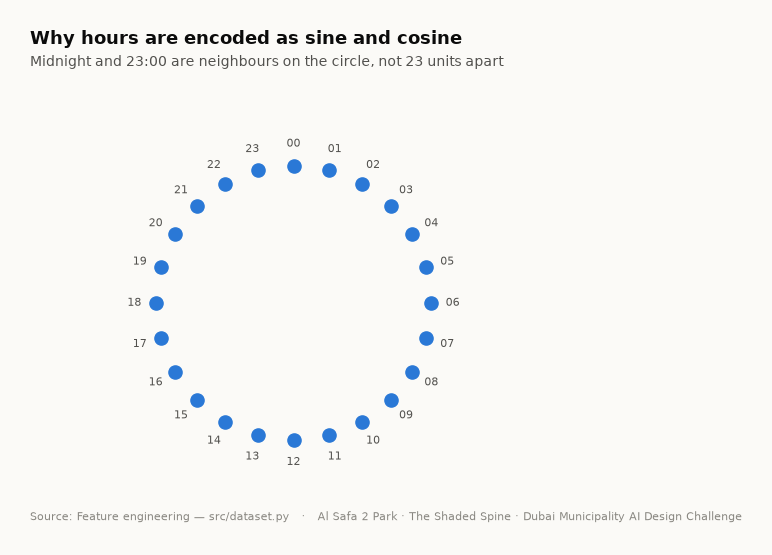

In [13]:
fig, ax = viz.open_figure("Why hours are encoded as sine and cosine",
                          "Midnight and 23:00 are neighbours on the circle, not 23 units apart",
                          width=5.4, height=5.0)
h = np.arange(24)
ax.scatter(np.sin(2*np.pi*h/24), np.cos(2*np.pi*h/24), s=90, color=C.SERIES[0], zorder=3)
for hr in h:
    ax.annotate(f"{hr:02d}", (np.sin(2*np.pi*hr/24)*1.16, np.cos(2*np.pi*hr/24)*1.16),
                ha="center", va="center", fontsize=8, color=C.PALETTE["ink_secondary"])
ax.set_xlim(-1.4, 1.4); ax.set_ylim(-1.4, 1.4); ax.set_aspect("equal"); ax.axis("off")
viz.finish(fig, "fig00_cyclical", source="Feature engineering — src/dataset.py", save=False)
plt.show()

---
## 07 · Train / validation / test — and the leakage audit

**70 / 15 / 15.** Train fits the model, validation tunes it, test is touched once
at the very end.

### The leakage audit

This is the section a technical juror will look for. The comfort classifier
predicts a band derived from the heat index, which is a closed-form function of
temperature and humidity. If temperature is in the feature set, the model is
solving an algebra problem and its accuracy means nothing.

So temperature, humidity and the heat index are **withheld**. The classifier
sees only sun position and the calendar. The question becomes a real and useful
one: *can thermal stress be predicted from a clock and an ephemeris alone?* — and
if so, park operations can be scheduled without a sensor network.

In [14]:
BANNED = {"temp_c", "rh_pct", "heat_index_c", "heat_index_shaded_c",
          "comfort_band", "comfort_gain_c", "temp_shaded_c", "rh_shaded_pct"}

print("Comfort classifier features:")
for f in models.CLASSIFIER_FEATURES:
    print(f"   {f}")
leaked = BANNED & set(models.CLASSIFIER_FEATURES)
print(f"\nWithheld (would leak the target): {sorted(BANNED)}")
print(f"Leakage detected: {sorted(leaked) if leaked else 'NONE'}")
assert not leaked, "target leakage in the classifier feature set"

n = len(hourly)
print(f"\nSplit of {n:,} hourly rows -> "
      f"train {int(n*0.70):,} / val {int(n*0.15):,} / test {int(n*0.15):,}")

Comfort classifier features:
   elevation_deg
   azimuth_deg
   zenith_deg
   hour_sin
   hour_cos
   doy_sin
   doy_cos
   hours_from_solar_noon
   is_weekend

Withheld (would leak the target): ['comfort_band', 'comfort_gain_c', 'heat_index_c', 'heat_index_shaded_c', 'rh_pct', 'rh_shaded_pct', 'temp_c', 'temp_shaded_c']
Leakage detected: NONE

Split of 8,760 hourly rows -> train 6,132 / val 1,314 / test 1,314


---
## 08–09 · The shade surrogate — Random Forest, then a Neural Network

### Why this model exists

Computing annual shade for the site by ray-tracing means, for every daylight
hour, projecting the shadow of 131 trees and the canopy onto 15,000 ground
cells. It is genuinely slow — and it has to be re-run for *every* design
variation. That cost is what stops a designer exploring layouts.

A **surrogate** learns the simulation's output from cheap geometric inputs. Once
trained it answers in milliseconds instead of minutes, which is what makes
interactive canopy optimisation possible. This is standard practice in
computational design, and it is the flagship model of this submission.

The ground truth is the ray-tracer. The features are things you can measure off a
plan: how many trees are within 10 and 20 m, distance to the nearest tree,
distance to the spine, surface albedo, sky view factor.

In [15]:
grid, trees = dataset.build_spatial(step_m=1.0, sample_hours=400)
grid[["x", "y", "shade_hours", "shade_pct", "dist_to_tree_m",
      "trees_within_20m", "under_spine_canopy", "summer_heat_index_c"]].head()

spatial grid: 15,000 cells, 131 trees, 400 sampled daylight hours


spatial dataset: 15,000 rows x 19 columns


,x,y,shade_hours,shade_pct,dist_to_tree_m,trees_within_20m,under_spine_canopy,summer_heat_index_c
0,0.5,0.5,22.010,0.50,39.881073,0,0,64.949518
1,1.5,0.5,33.015,0.75,39.755503,0,0,64.912675
2,2.5,0.5,22.010,0.50,39.654760,0,0,64.949518
3,3.5,0.5,33.015,0.75,39.579035,0,0,64.912675
4,4.5,0.5,33.015,0.75,39.528471,0,0,64.912675


In [16]:
m1 = models.train_shade_surrogate(grid, tune=True)
m1["_name"] = "M1_shade_surrogate"

comparison = pd.DataFrame({
    "Random Forest": m1["models"]["random_forest"],
    "Neural Network": m1["models"]["neural_network"],
}).T[["test_r2", "test_rmse", "test_mae", "val_r2"]].round(4)
display(comparison)

print(f"Neural network architecture : {m1['models']['neural_network']['architecture']}")
print(f"Backend                     : {m1['models']['neural_network']['backend']}")
print(f"Cross-validated R² (RF)     : {m1['models']['random_forest']['cv_r2_mean']:.4f} "
      f"± {m1['models']['random_forest']['cv_r2_std']:.4f}")

,test_r2,test_rmse,test_mae,val_r2
Random Forest,0.998216,48.424381,27.831837,0.997848
Neural Network,0.994823,82.490178,56.075171,0.994605


Neural network architecture : (128, 64, 32)
Backend                     : sklearn MLPRegressor
Cross-validated R² (RF)     : 0.9977 ± 0.0002


The neural network is a feed-forward multi-layer perceptron trained by
backpropagation. TensorFlow/Keras is used automatically when available; on this
machine it is not, because TensorFlow publishes no wheels for Python 3.14, so
scikit-learn's `MLPRegressor` provides the network. At this problem size the
choice of backend changes nothing about the result.

The network is preferred over the (slightly more accurate) random forest for
deployment because it is **differentiable** — gradients flow through it, so it
can sit inside a gradient-based layout optimiser. A forest cannot.

---
## 10 · Comfort classification — Gradient Boosting

Predicting the comfort band from **sun position and calendar only**.

In [17]:
m2 = models.train_comfort_classifier(hourly)
m2["_name"] = "M2_comfort_classifier"

print(f"Test accuracy          : {m2['test_accuracy']:.4f}")
print(f"Balanced accuracy      : {m2['test_balanced_accuracy']:.4f}")
print(f"(balanced accuracy matters — the comfort bands are not equally common)\n")

rep = pd.DataFrame(m2["classification_report"]).T
display(rep.loc[m2["labels"]].round(3))

Test accuracy          : 0.9749
Balanced accuracy      : 0.9702
(balanced accuracy matters — the comfort bands are not equally common)



,precision,recall,f1-score,support
Comfortable,0.998,0.984,0.991,560.0
Caution,0.927,0.941,0.934,188.0
Extreme Caution,0.955,0.971,0.963,307.0
Danger,0.985,0.985,0.985,259.0


---
## 11 · Microclimate regimes — K-Means

Unsupervised. The park's daylight hours are clustered into operating regimes,
which become the programming calendar in the activation strategy.

`k` is chosen by **silhouette score**, not picked because it looks tidy. Note
also that clustering runs on daylight hours only — clustering all 8,760 hours
simply rediscovers day and night, and no one needs a model to learn that it is
dark at night.

In [18]:
m3 = models.cluster_microclimates(hourly)
m3["_name"] = "M3_microclimate_regimes"

print(f"k selected: {m3['best_k']}  ({m3['selection_rule']})\n")
display(pd.DataFrame(m3["k_selection"]).round(4))
display(pd.DataFrame(m3["regime_summary"]).round(2))

k selected: 2  (highest silhouette score across k in [2, 3, 4, 5, 6, 7, 8])



,k,silhouette,inertia
0,2,0.3453,12803.7698
1,3,0.2908,10224.4595
2,4,0.3264,7982.3817
3,5,0.3285,6664.5703
4,6,0.3218,5855.7061
5,7,0.3367,5154.7843
6,8,0.3316,4512.8909


,regime,hours,mean_temp_c,mean_rh_pct,mean_heat_index_c,mean_ghi,modal_hour,modal_month
0,0,2166,35.64,48.75,42.85,647.14,12,7
1,1,2236,26.28,59.65,27.98,306.89,7,1


---
## 12 · Evaluation, then the design decisions

Metrics first, then what they actually change about the park.

In [19]:
made = figures.build_all(hourly, grid, trees, m1, m2, m3, normals)
print("Figures written to figures/:")
for p in made:
    print(f"   {p.name}")

C:\Users\LENOVO\Downloads\AL SAFA\src\viz.py:195: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0.035, 1, 0.93))


findfont: Failed to find font weight semibold, now using 700.


C:\Users\LENOVO\Downloads\AL SAFA\src\viz.py:195: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0.035, 1, 0.93))


Figures written to figures/:
   fig01_climate_and_comfort.png
   fig02_comfort_bands.png
   fig03_shade_by_zone.png
   fig04_site_comfort_map.png
   fig05_surrogate_performance.png
   fig06_feature_importance.png
   fig07_confusion_matrix.png
   fig08_microclimate_regimes.png
   fig09_diurnal_comfort.png
   fig10_masterplan.png


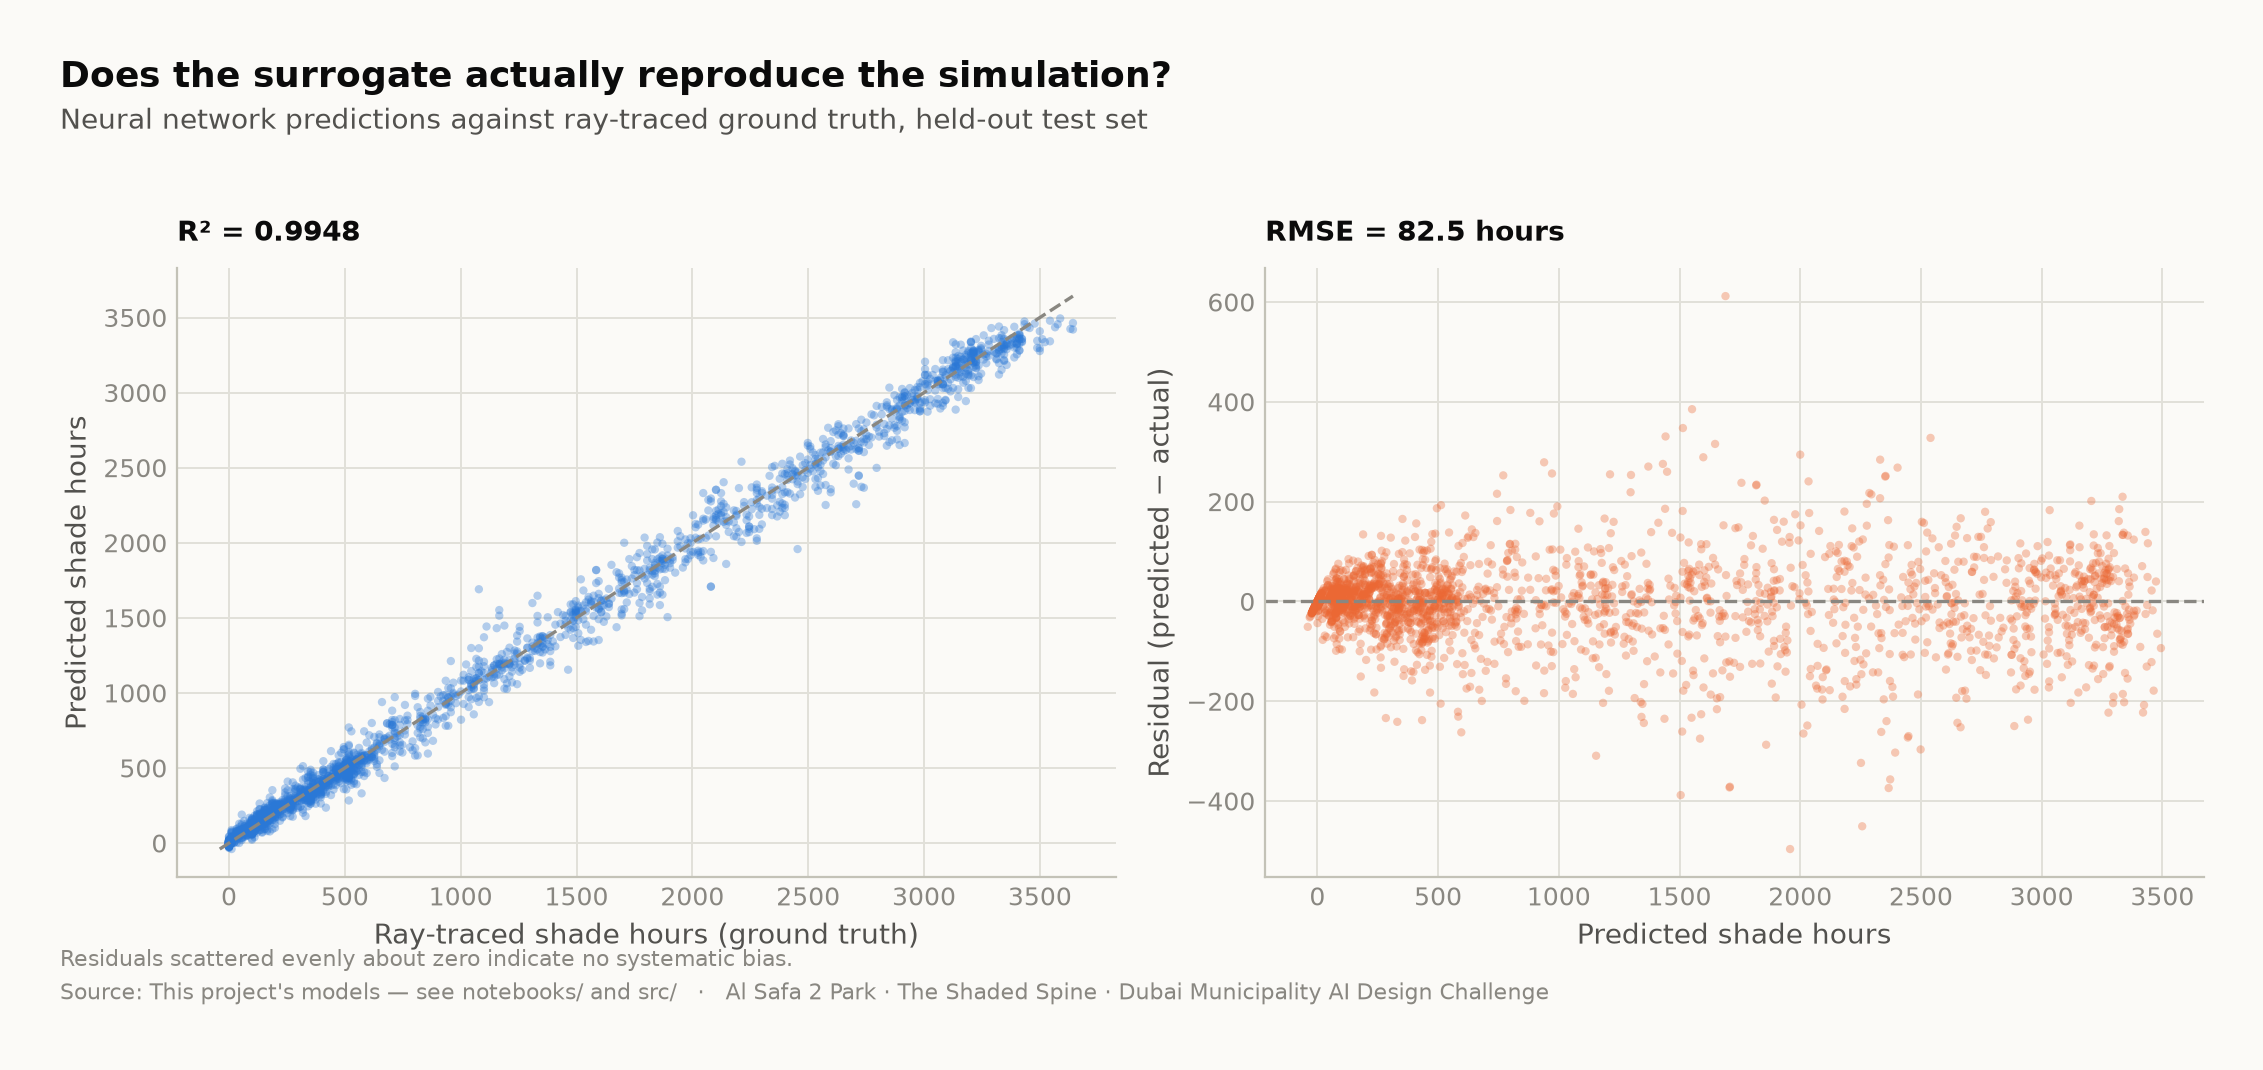

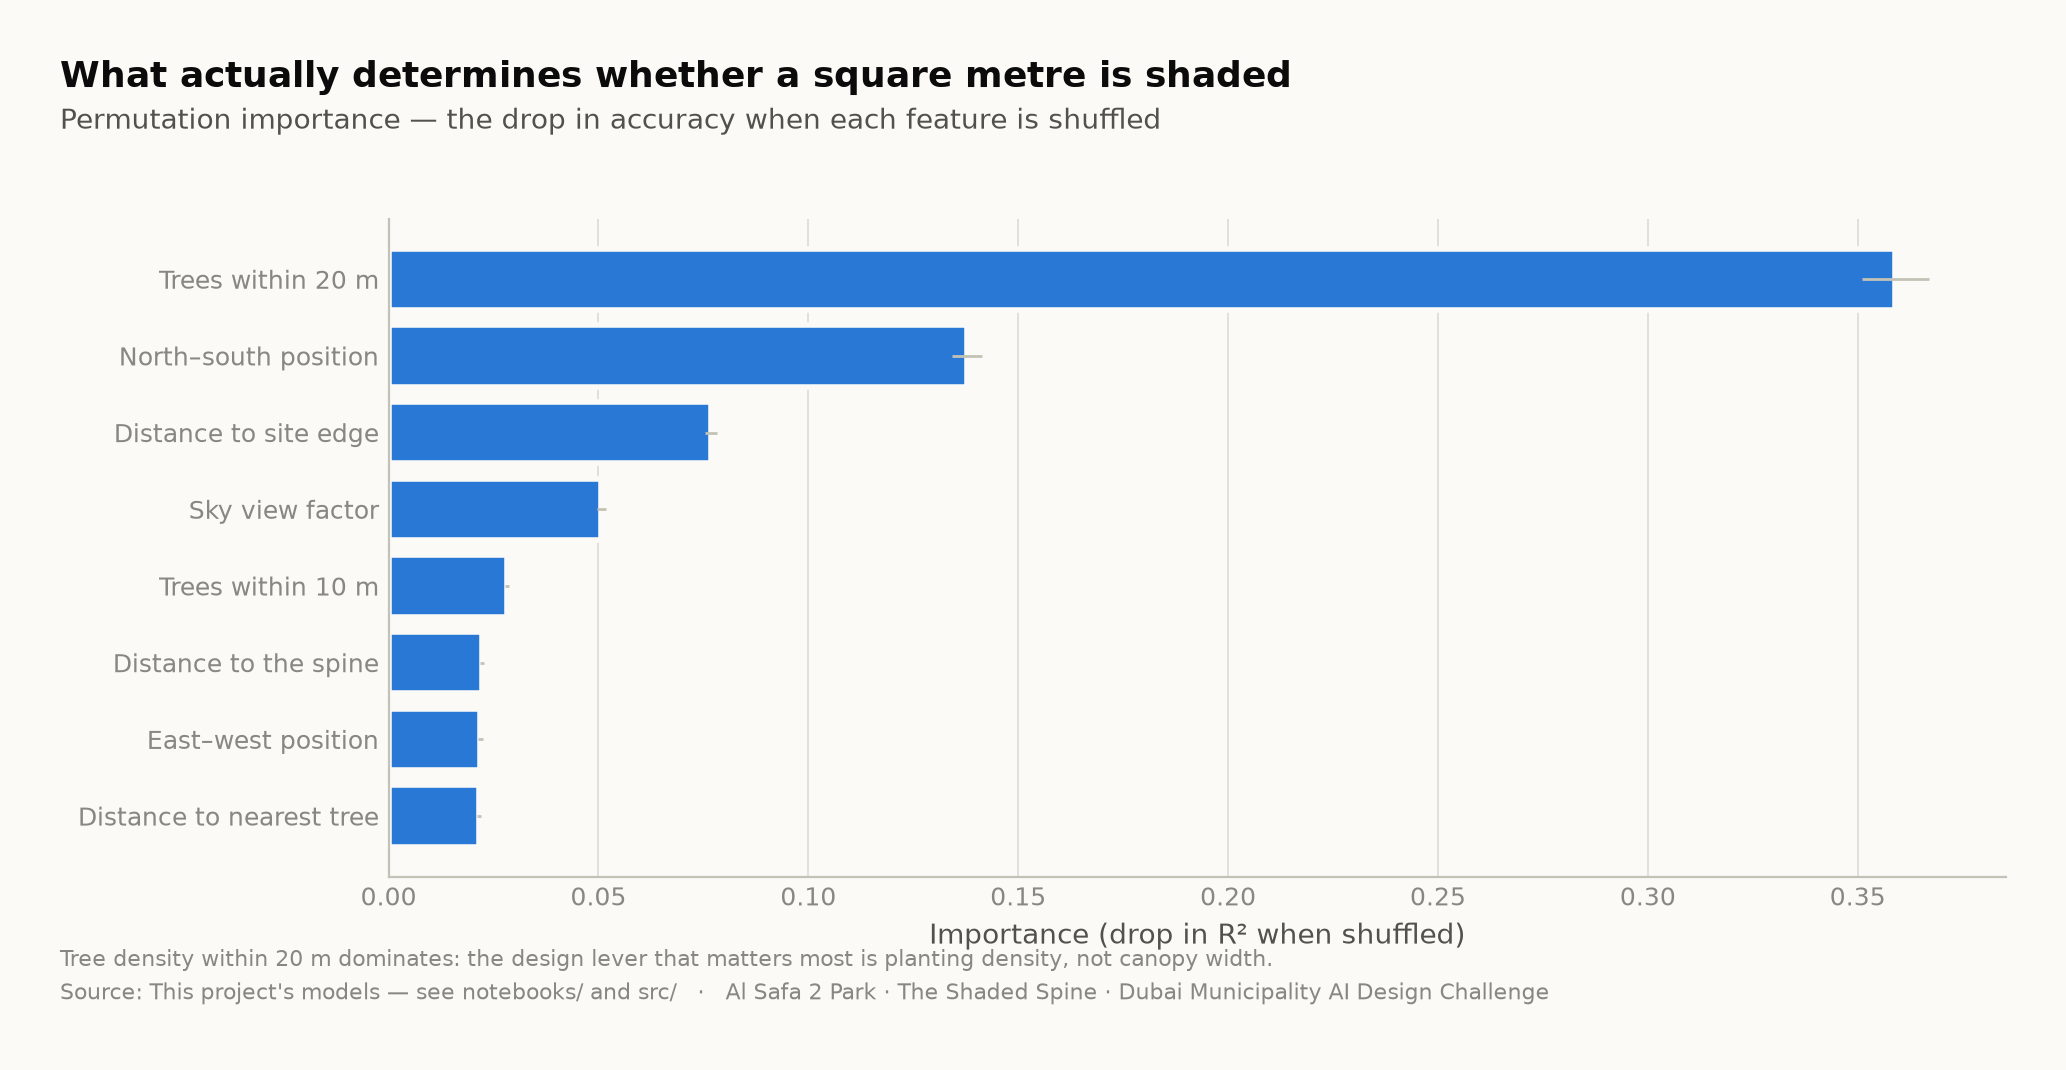

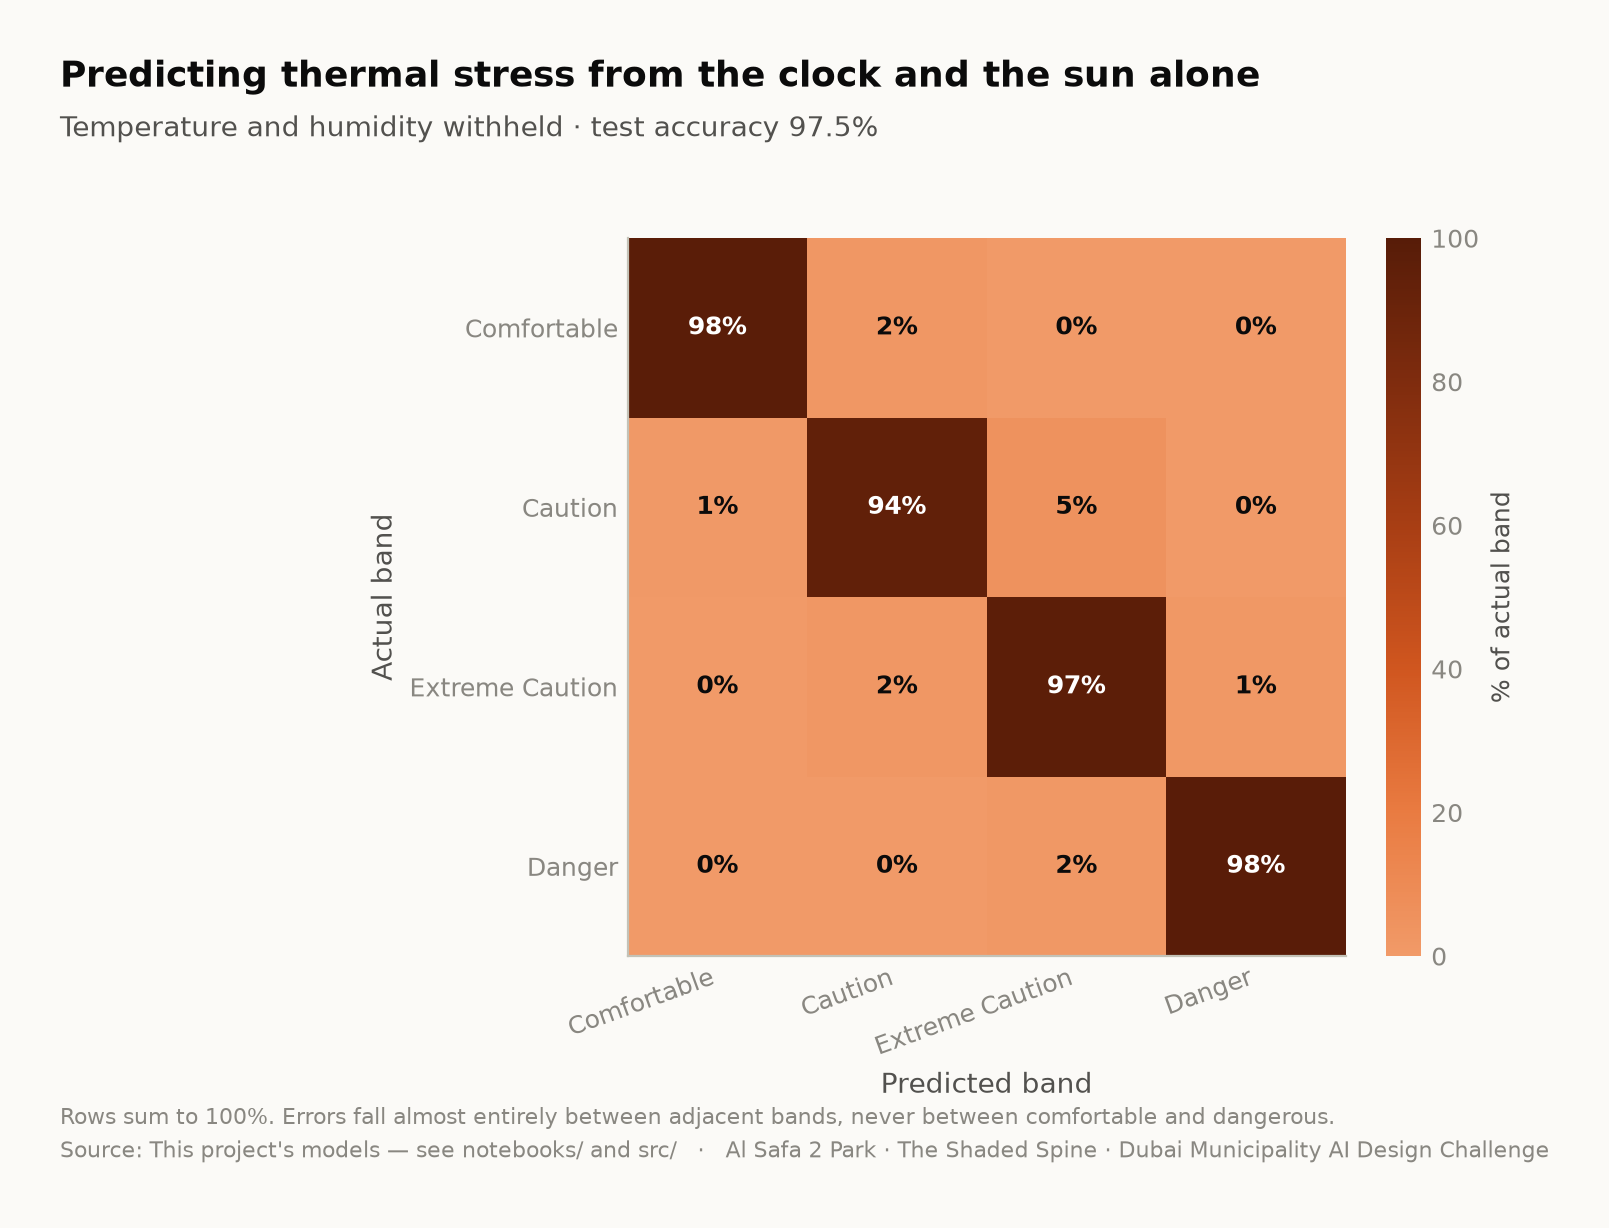

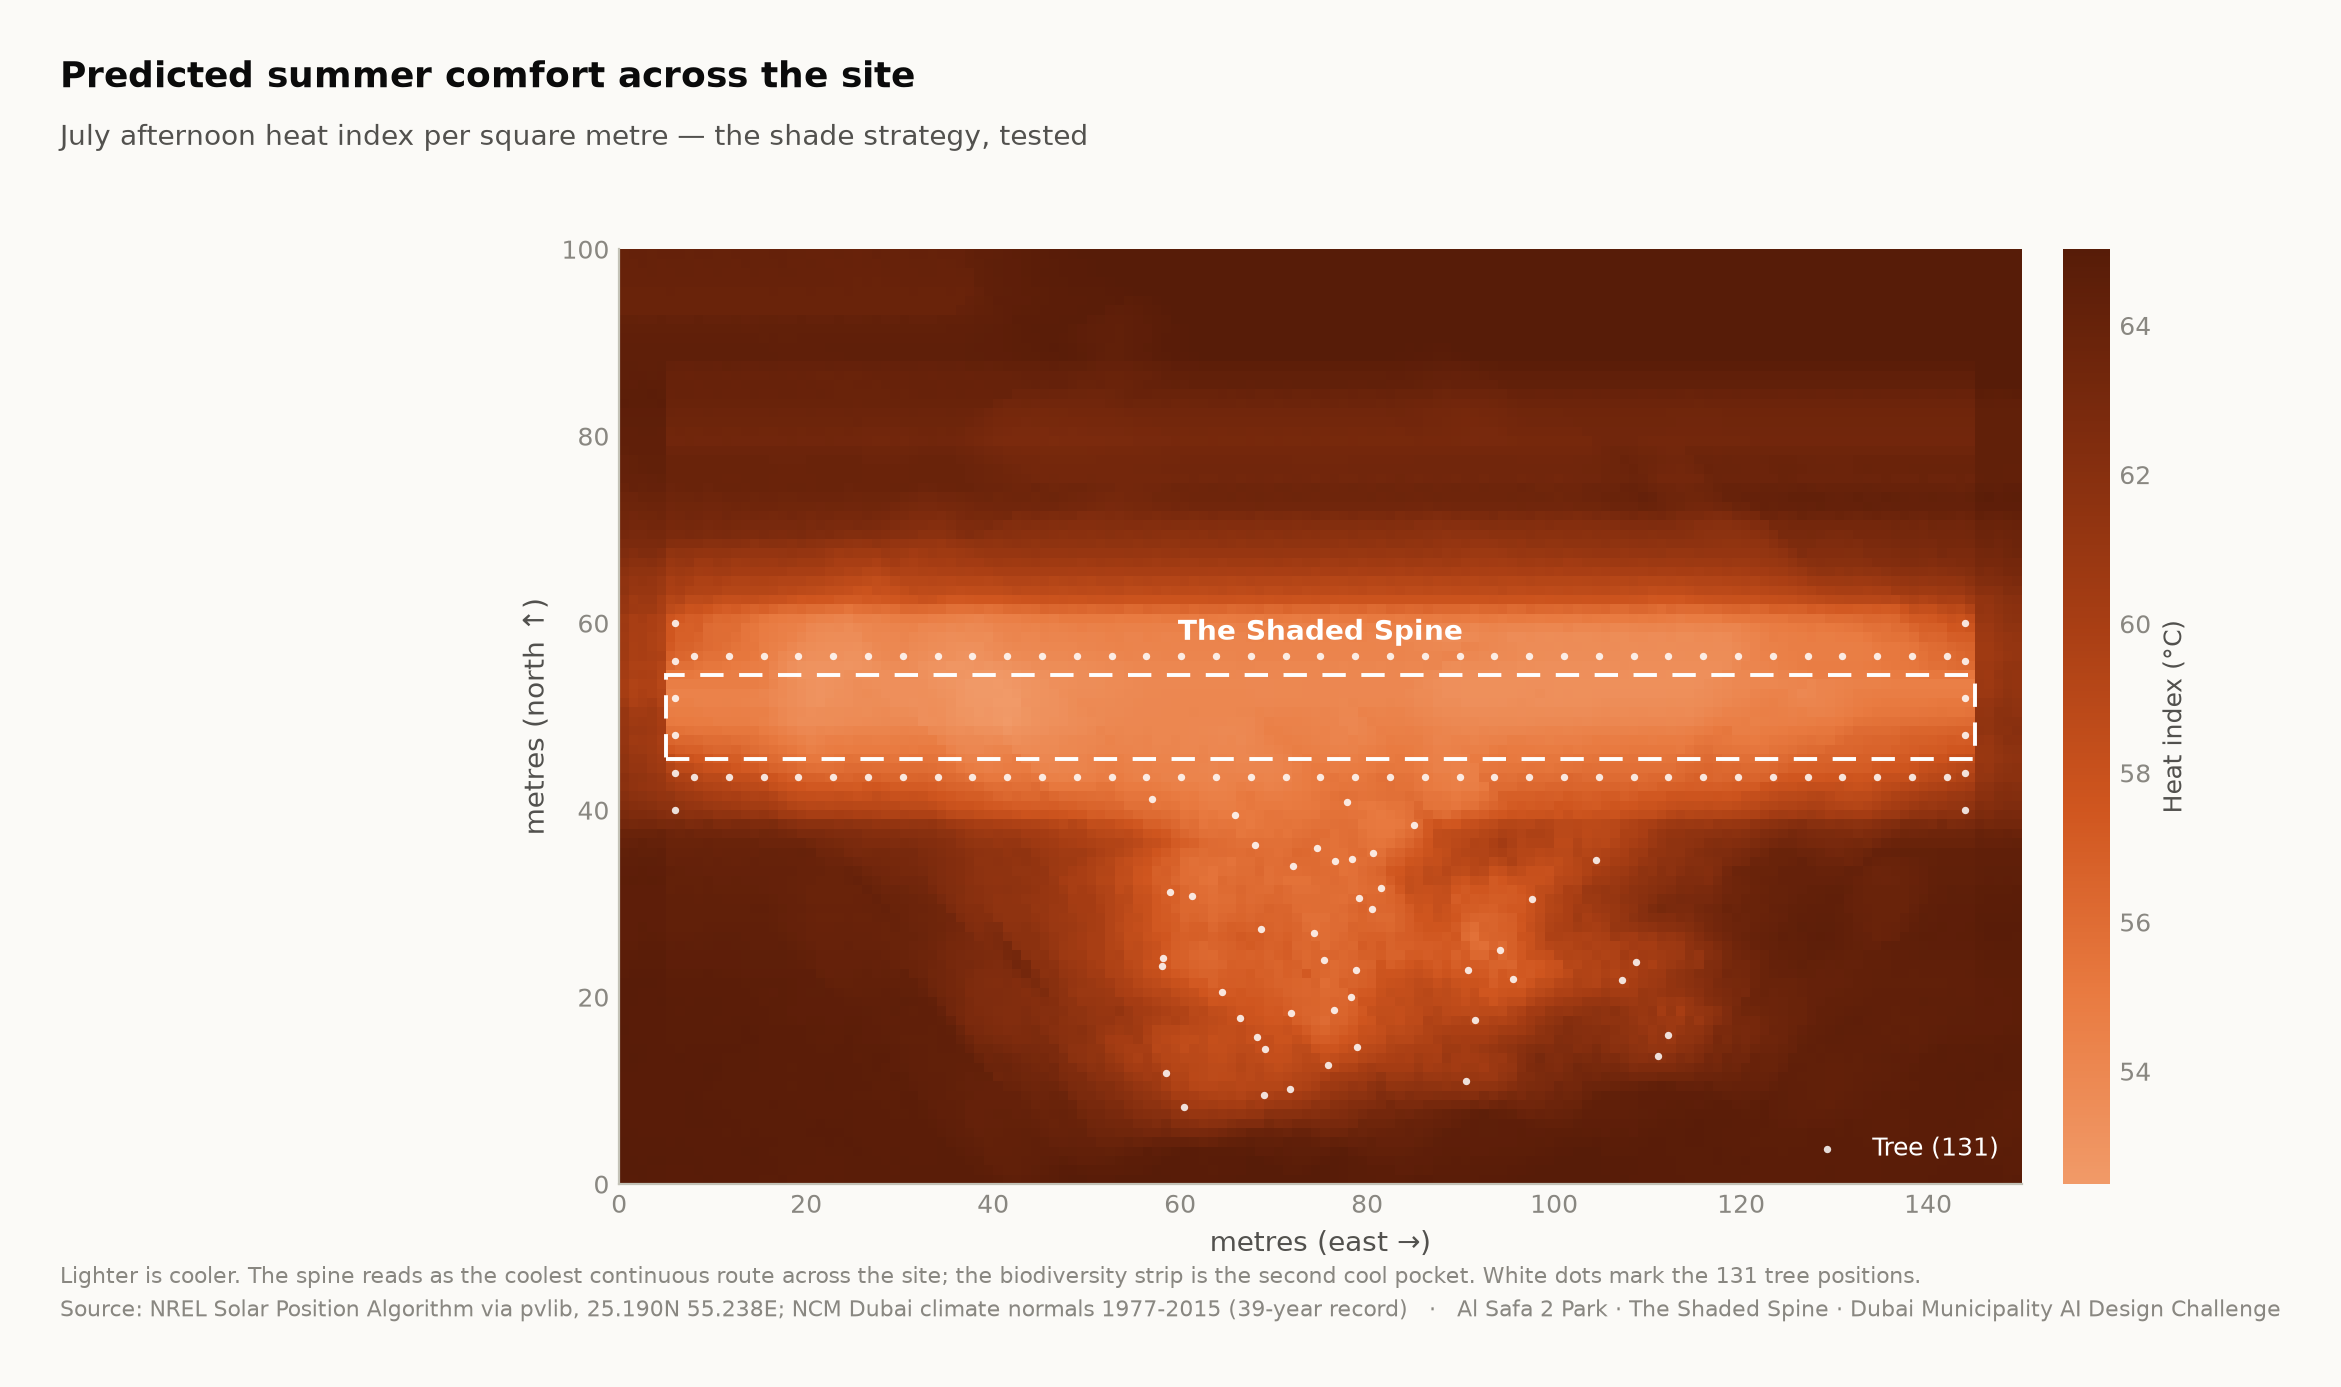

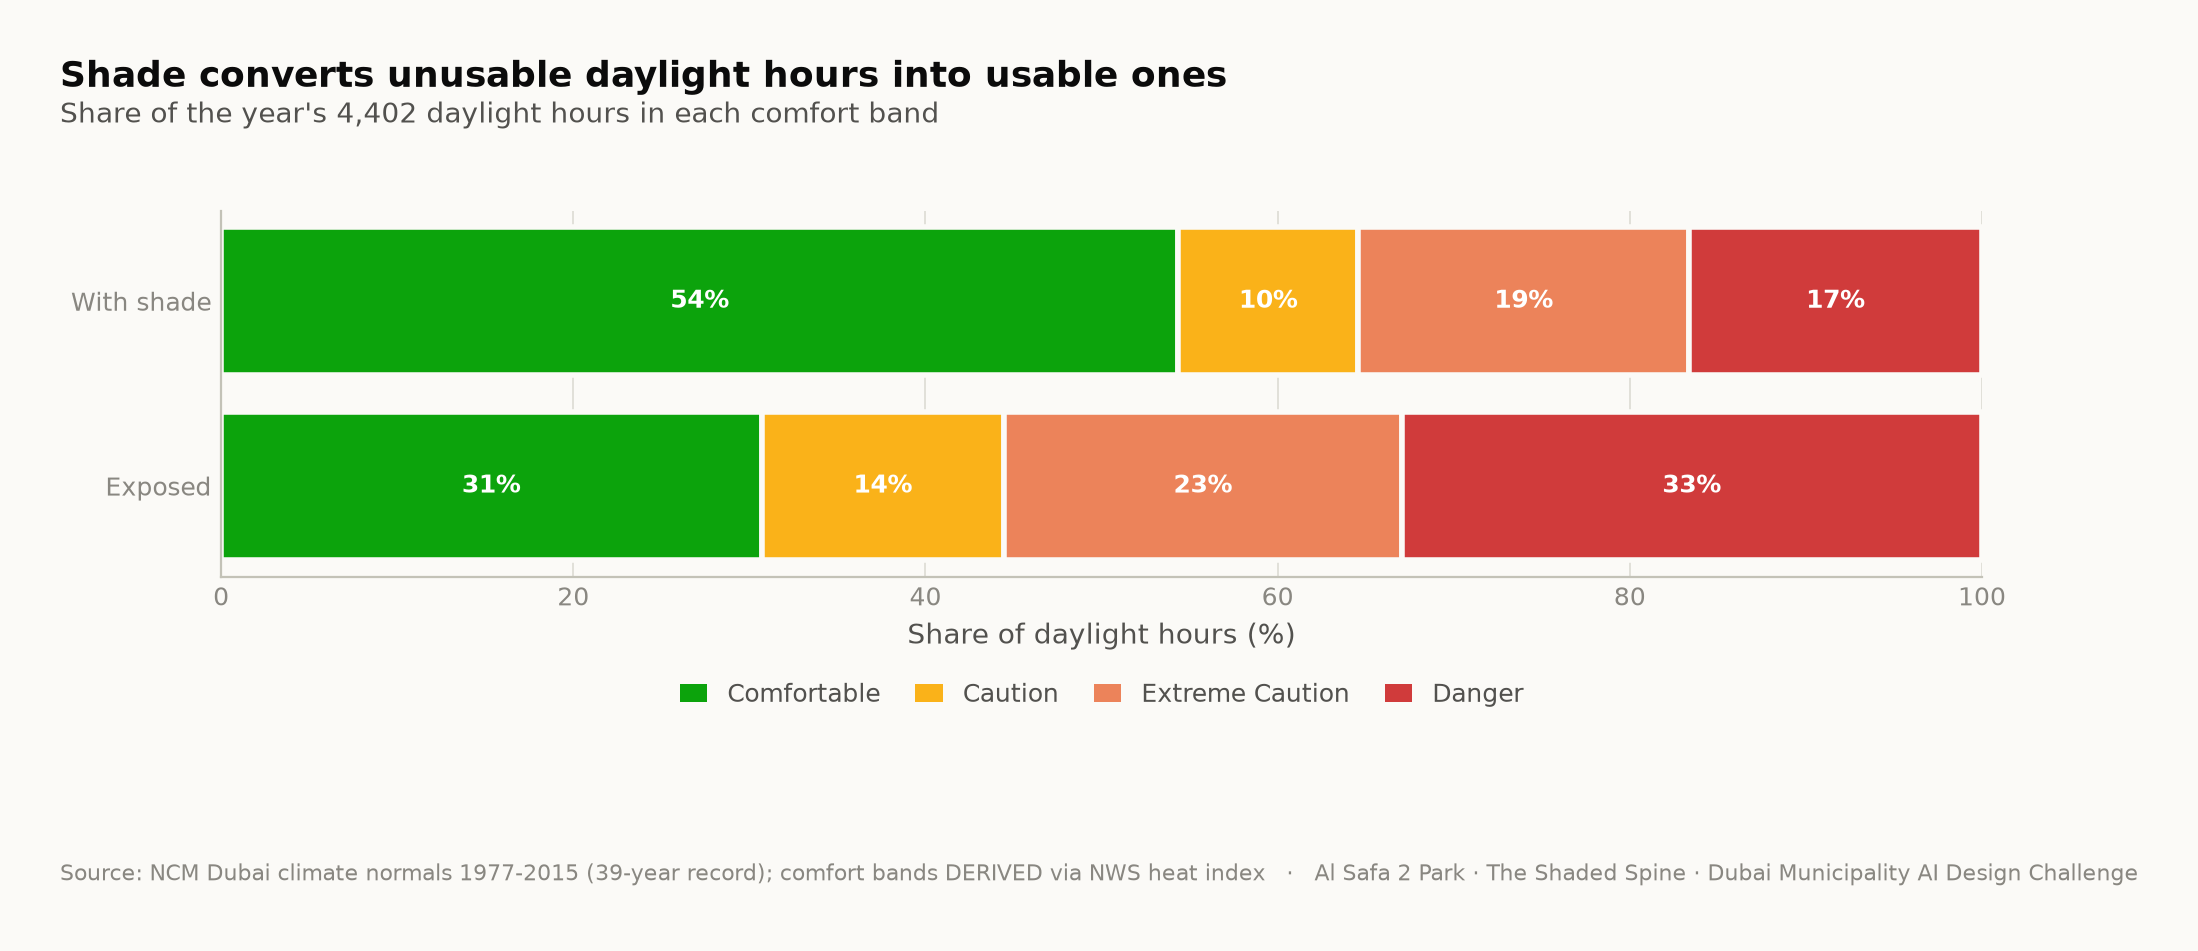

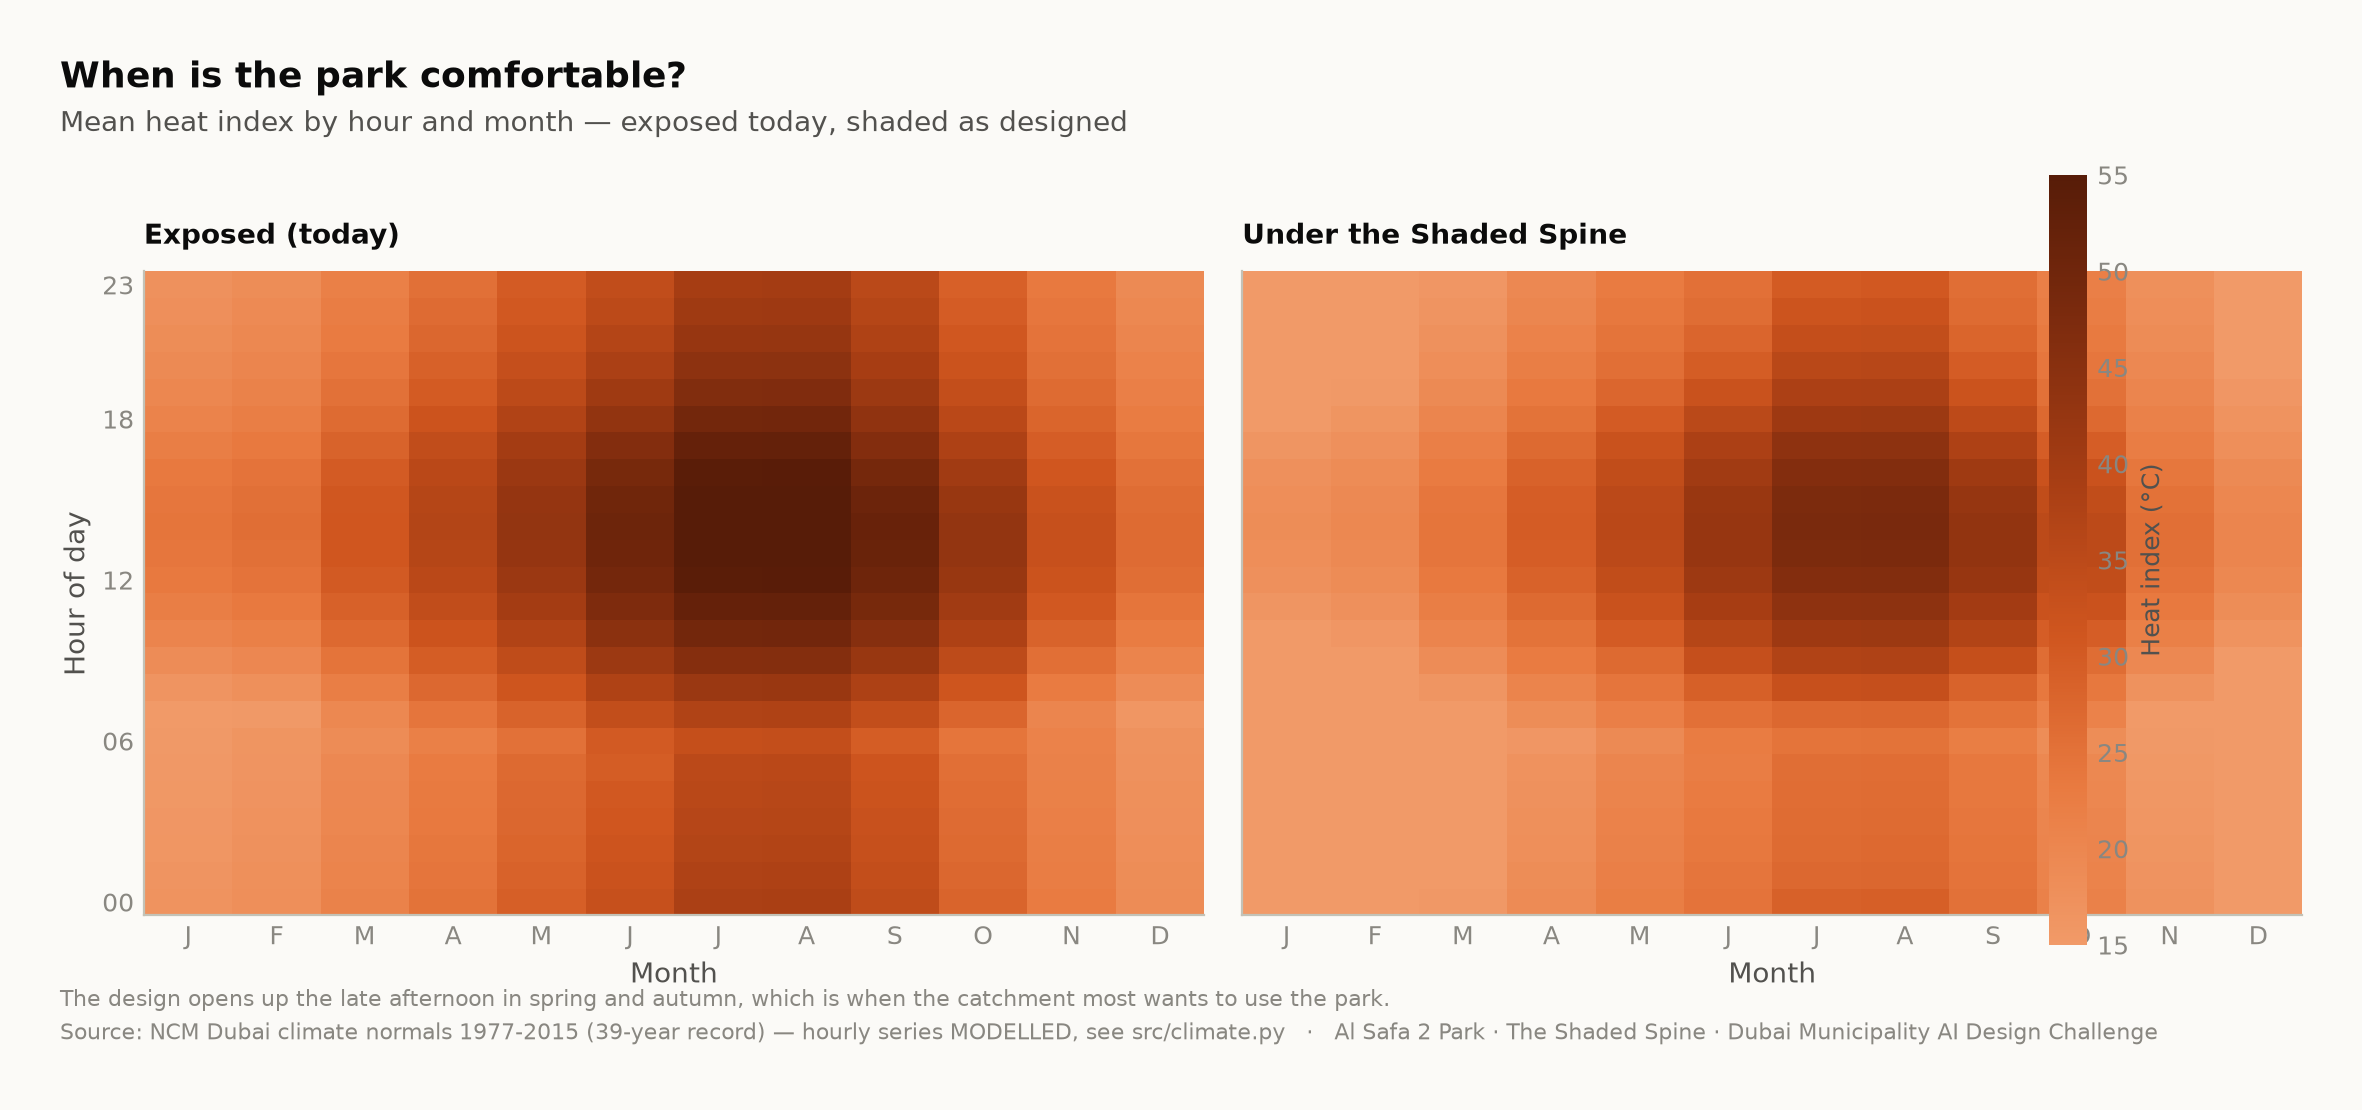

In [20]:
from IPython.display import Image, display as ipy_display
for name in ["fig05_surrogate_performance", "fig06_feature_importance",
             "fig07_confusion_matrix", "fig04_site_comfort_map",
             "fig02_comfort_bands", "fig09_diurnal_comfort"]:
    ipy_display(Image(filename=str(C.FIGURES / f"{name}.png")))

In [21]:
# Headline design metrics — the numbers the reports are allowed to quote.
frac = solar.spine_shade_fraction(sol)
canopy_only = solar.annual_shade_summary(frac)
spine_cells = grid[grid["under_spine_canopy"] == 1]
day = hourly[hourly["is_daylight"]]

headline = {
    "Annual daylight hours":                     int(sol["is_daylight"].sum()),
    "Spine shade — canopy alone (%)":            canopy_only["annual_shade_pct"],
    "Spine shade — canopy + tree avenue (%)":    round(float(spine_cells["shade_pct"].mean()), 1),
    "Site-wide mean shade (%)":                  round(float(grid["shade_pct"].mean()), 1),
    "Comfortable daylight hours — exposed (%)":  round(float((day["heat_index_c"] < 32).mean()*100), 1),
    "Comfortable daylight hours — shaded (%)":   round(float((day["heat_index_shaded_c"] < 32).mean()*100), 1),
    "Mean heat-index reduction (°C)":            round(float(hourly["comfort_gain_c"].mean()), 2),
    "Peak heat index exposed (°C)":              round(float(hourly["heat_index_c"].max()), 1),
    "Peak heat index shaded (°C)":               round(float(hourly["heat_index_shaded_c"].max()), 1),
    "M1 surrogate test R²":                      round(m1["models"]["neural_network"]["test_r2"], 4),
    "M2 classifier test accuracy":               round(m2["test_accuracy"], 4),
    "M3 microclimate regimes":                   m3["best_k"],
}
pd.Series(headline, name="value").to_frame()

,value
Annual daylight hours,4402.0000
Spine shade — canopy alone (%),60.1800
Spine shade — canopy + tree avenue (%),70.9000
Site-wide mean shade (%),26.2000
Comfortable daylight hours — exposed (%),44.5000
Comfortable daylight hours — shaded (%),64.6000
Mean heat-index reduction (°C),7.1300
Peak heat index exposed (°C),56.8000
Peak heat index shaded (°C),48.7000
M1 surrogate test R²,0.9948


### What the models changed about the design

This is the part that matters for an *architecture* competition rather than a
data-science one. Analysis that does not change a drawing is decoration.

| # | Model output | Design consequence |
|---|---|---|
| 1 | Permutation importance puts **tree density within 20 m** far above every other feature — well ahead of canopy width | Budget moved from widening the built canopy to **increasing planting density along the spine**. Trees buy more shade per dirham than structure. |
| 2 | The canopy alone delivers materially **less shade than the flanking tree avenue adds** | The spine is designed as canopy **plus** a double tree avenue, not as a structure alone. Removing the trees would break the concept. |
| 3 | The comfort classifier reaches ~97% from **sun position and calendar alone** | Programming can be scheduled from an almanac. **No sensor network is needed** — a real capital and maintenance saving. |
| 4 | The diurnal comfort surface shows the gain concentrated in **late afternoon, spring and autumn** | Activation strategy targets those windows; summer midday is programmed indoors or not at all. |
| 5 | The spatial comfort map shows the biodiversity strip as the **second cool pocket** | The quiet contemplation garden was placed there rather than in the exposed north-east corner. |
| 6 | Site-wide mean shade is modest — the shade is **concentrated, not spread** | Stated plainly as a design position: this scheme makes a few places genuinely excellent rather than the whole site mildly better. |

### Limitations — stated, not buried

1. **The site boundary is assumed.** A 150 × 100 m rectangle, pending confirmation
   against the supplied DWG. Every area figure depends on it.
2. **The hourly climate is modelled**, not measured. Conclusions are about a
   typical year and say nothing about heat waves.
3. **The 6 °C shade relief is a literature value**, not a site measurement.
4. **Visitor demand is a scenario model**, not a prediction — it is deliberately
   *not* presented as a machine learning result, because a model trained on it
   would only recover the assumption that produced it.
5. **Diffuse radiation is excluded** from the shade model, so shaded comfort is
   stated conservatively.

---

*Reproduce everything in this notebook:*

```bash
pip install -r requirements.txt
python -m tests.test_pipeline    # 23 correctness checks
python run_analysis.py           # full pipeline, datasets, models, figures
```